In [1]:
from dotenv import load_dotenv
import os
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('../env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
MODEL_API_VERSION=os.getenv('MODEL_API_VERSION')
if MODEL_API_VERSION:
    os.environ['MODEL_API_VERSION'] = MODEL_API_VERSION
if AZURE_OPENAI_API_KEY:
    print(AZURE_OPENAI_API_KEY[:10])
else:
    print("AZURE_OPENAI_API_KEY가 설정되지 않았습니다.")
print(MODEL_NAME, MODEL_API_VERSION)

langsmith_key = os.getenv('LANGSMITH_API_KEY')
if langsmith_key:
    os.environ['LANGCHAIN_API_KEY'] = langsmith_key
ep = os.getenv('LANGCHAIN_ENDPOINT')
if ep:
    os.environ['LANGCHAIN_ENDPOINT'] = ep
os.environ['LANGCHAIN_TRACING_V2'] = 'false' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'AGENT'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    _lk = os.getenv('LANGSMITH_API_KEY')
    if _lk and len(_lk) > 0:
        print('랭스미스로 추적 중입니다 :', _lk[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

3BHTZdVIXx
gpt-5-nano 2025-01-01-preview


In [2]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,
    azure_deployment=MODEL_NAME,
    api_version=os.environ.get('MODEL_API_VERSION', '2024-12-01-preview'),
    model = MODEL_NAME,
    # temperature=0.2,
)

## 오케스트레이션 - 여행 플랜 작성기

이번 파일에서는 이전에 만든 여행 플랜 작성기를 조금 더 개선해 보겠습니다.

In [3]:
import textwrap, requests, os
from typing import TypedDict, List, Dict, Any, Optional, Literal, Annotated
from datetime import date, timedelta
from dateutil import parser as dateparser
import json

from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_tavily import TavilySearch

USE_OVERPASS = True
OPEN_METEO_GEOCODE = "https://geocoding-api.open-meteo.com/v1/search"
OPEN_METEO_FORECAST = "https://api.open-meteo.com/v1/forecast"
WIKI_SUMMARY      = "https://en.wikipedia.org/api/rest_v1/page/summary/{}"
WIKI_SEARCH       = "https://en.wikipedia.org/w/api.php"
WIKI_REST_SEARCH  = "https://en.wikipedia.org/w/rest.php/v1/search/title"
HEADERS = {"User-Agent": "AgenticTravel/1.0 (contact: you@example.com)"}
OVERPASS_API = "https://overpass-api.de/api/interpreter"
# Tavily: 관광지 등 능동 검색용 (TAVILY_API_KEY 필요)
_tavily_api = os.getenv("TAVILY_API_KEY")
TAVILY_SEARCH = TavilySearch(max_results=10, api_key=_tavily_api) if _tavily_api else None

# 여행을 위한 파라미터
RAIN_MM_OK = 0.2 # 이정도 비는 괜찮아
WIND_MPS_MAX = 9.0 # 이정도 바람까지 괜찮아
TEMP_MIN_C = 10.0 # 최저 기온
TEMP_MAX_C = 30.0 #최고 기온

MAX_REVISIONS = 3

def _fmt_day(d: date) -> str:
    return d.strftime("%Y-%m-%d")

def _date_range(start: date, nights: int) -> List[date]:
    return [start + timedelta(days=i) for i in range(nights + 1)]

def _iso_to_date(s: str) -> date:
    return dateparser.parse(s).date()

{
  "destination": "Paris",
  "start_date": "2026-2-27",
  "nights": 3,
  "preferences": "I like to eat out and go to museums",
  "tz": "Europe/Paris",
  "lat": 48.85341,
  "lon": 2.3488,
  "weather": {
    "latitude": 48.86,
    "longitude": 2.3399997,
    "generationtime_ms": 0.24449825286865234,
    "utc_offset_seconds": 3600,
    "timezone": "Europe/Paris",
    "timezone_abbreviation": "GMT+1",
    "elevation": 43.0,
    "hourly_units": {
      "time": "iso8601",
      "temperature_2m": "\u00b0C",
      "precipitation": "mm",
      "windspeed_10m": "km/h"
    },
    "hourly": {
      "time": [
        "2026-02-27T00:00",
        "2026-02-27T01:00",
        "2026-02-27T02:00",
        "2026-02-27T03:00",
        "2026-02-27T04:00",
        "2026-02-27T05:00",
        "2026-02-27T06:00",
        "2026-02-27T07:00",
        "2026-02-27T08:00",
        "2026-02-27T09:00",
        "2026-02-27T10:00",
        "2026-02-27T11:00",
        "2026-02-27T12:00",
        "2026-02-27T13:00",
   

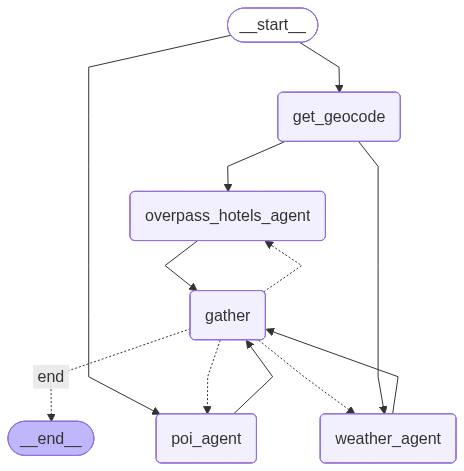

In [4]:
class CollectState(TypedDict, total=False):
    # 유저의 입력값 (여행 정보)
    destination: str
    start_date: str  # YYYY-MM-DD
    nights: int
    preferences: str

    # 데이터 조회 결과
    tz: str
    lat: float
    lon: float
    weather: Dict[str, Any]
    wiki_summary: str
    pois: List[Dict[str, Any]]
    hotels: List[Dict[str, Any]]

    # 소스별 재시도 횟수
    weather_retries: Annotated[int, lambda a, b: b]
    poi_retries: Annotated[int, lambda a, b: b]
    hotels_retries: Annotated[int, lambda a, b: b]
    gather_next: Annotated[str, lambda a, b: b]  # "weather_agent" | "poi_agent" | "overpass_hotels_agent" | "end"


MAX_RETRY_PER_SOURCE = 2  # 소스별 최대 재수집 횟수, 초과 시 넘어감


def get_geocode(state: CollectState) -> Dict:
    """위도, 경도, 타임존 조회"""
    dest = state["destination"]
    prompt = ChatPromptTemplate.from_template(
        """
        여행자의 목적지 문장을 받아서 지역의 이름을 영어로 추출하세요.

        예시:
        - 미국 뉴욕 --> New York
        - 일본 도쿄 --> Tokyo
        - 프랑스 파리 --> Paris
        - 이탈리아 로마 --> Rome
        - 스페인 바르셀로나 --> Barcelona

        입력 장소 : {dest}
        """
    )
    chain = prompt | llm | StrOutputParser()
    dest = chain.invoke({"dest": dest})

    r = requests.get(OPEN_METEO_GEOCODE, params={"name": dest, "count": 1, "language": "en"}, timeout=20)
    r.raise_for_status()
    results = r.json().get("results") or []

    if not results:
        raise RuntimeError("Destination not found")

    top = results[0]
    lat, lon = float(top["latitude"]), float(top["longitude"])
    tz = top.get("timezone") or "UTC"

    return {"lat": lat, "lon": lon, "tz": tz, "destination": dest}

def _weather_agent_impl(state: CollectState) -> Dict:
    lat, lon = float(state["lat"]), float(state["lon"])
    tz = state["tz"]
    start = _iso_to_date(state["start_date"])
    end = start + timedelta(days=max(1, state["nights"]))
    today = date.today()
    start = max(today - timedelta(days=92), min(start, today + timedelta(days=16)))
    end = min(today + timedelta(days=16), max(end, start))
    if start > end:
        end = start
    f = requests.get(OPEN_METEO_FORECAST, params={
        "latitude": lat, "longitude": lon,
        "hourly": ["temperature_2m", "precipitation", "windspeed_10m"],
        "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "precipitation_hours", "wind_speed_10m_max"],
        "timezone": tz,
        "start_date": _fmt_day(start),
        "end_date": _fmt_day(end),
    }, timeout=30)
    f.raise_for_status()
    return {"weather": f.json()}


def weather_agent(state: CollectState) -> Dict:
    """날씨 수집. 실패 시 weather=None 반환해 gather에서 재수집 요청 가능."""
    try:
        return _weather_agent_impl(state)
    except Exception:
        return {"weather": None}


def _tavily_to_pois(dest: str, max_total: int = 30) -> List[Dict[str, Any]]:
    """Tavily로 여러 쿼리를 실행해 추천 여행지 POI 목록 수집 (중복 제거)."""
    if not TAVILY_SEARCH:
        return []
    seen_urls: set = set()
    pois: List[Dict[str, Any]] = []
    queries = [
        f"{dest} best tourist attractions must see",
        f"{dest} top things to do recommended",
        f"{dest} places to visit travel guide",
        f"{dest} must see sights and activities",
    ]
    for q in queries:
        if len(pois) >= max_total:
            break
        try:
            out = TAVILY_SEARCH.invoke(q)
            items = out if isinstance(out, list) else (getattr(out, "results", []) or [])
            for doc in items:
                if len(pois) >= max_total:
                    break
                url = (getattr(doc, "metadata", {}) or {}).get("url", "") or (doc.get("url", "") if isinstance(doc, dict) else "")
                if url and url in seen_urls:
                    continue
                seen_urls.add(url)
                _meta = getattr(doc, "metadata", None) or (doc if isinstance(doc, dict) else {})
                title = ((_meta.get("title") or (doc.get("title", "") if isinstance(doc, dict) else "") or ""))[:120]
                snippet = (getattr(doc, "page_content", None) or (doc.get("content", "") if isinstance(doc, dict) else "") or "")[:600]
                pois.append({"title": title or "(No title)", "snippet": snippet, "url": url or ""})
        except Exception:
            continue
    return pois

def poi_agent(state: CollectState) -> Dict:
    """관광지 정보 수집: Wikipedia 요약 + Wikipedia POI + Tavily 능동 검색."""
    dest = state["destination"].strip()
    summary = ""
    try:
        s = requests.get(WIKI_SUMMARY.format(requests.utils.quote(dest)), headers=HEADERS, timeout=20)
        if s.ok:
            summary = s.json().get("extract") or ""
    except Exception:
        pass

    pois: List[Dict[str, Any]] = []
    params = {"action":"query","list":"search","srsearch":f"{dest} tourist attractions OR museums OR parks OR markets","srlimit":12,"format":"json"}
    try:
        q = requests.get(WIKI_SEARCH, params=params, headers=HEADERS, timeout=20)
        if q.ok:
            hits = q.json().get("query", {}).get("search", [])
            for h in hits[:10]:
                title = h.get("title")
                pois.append({"title": title, "snippet": h.get("snippet", ""), "url": f"https://en.wikipedia.org/wiki/{requests.utils.quote(title or '')}"})
        else:
            r = requests.get(WIKI_REST_SEARCH, params={"q": dest, "limit": 12}, headers=HEADERS, timeout=20)
            if r.ok:
                for item in (r.json().get("pages") or [])[:10]:
                    title = item.get("title")
                    pois.append({"title": title, "snippet": item.get("description",""), "url": f"https://en.wikipedia.org/wiki/{requests.utils.quote(title or '')}"})
    except Exception:
        pass

    tavily_pois = _tavily_to_pois(dest, max_total=25)
    seen = {p.get("url") or p.get("title") for p in pois}
    for p in tavily_pois:
        if (p.get("url") or p.get("title")) not in seen:
            seen.add(p.get("url") or p.get("title"))
            pois.append(p)

    return {"wiki_summary": summary or "", "pois": pois}


def _poi_agent_impl(state: CollectState) -> Dict:
    dest = state["destination"].strip()
    summary = ""
    try:
        s = requests.get(WIKI_SUMMARY.format(requests.utils.quote(dest)), headers=HEADERS, timeout=20)
        if s.ok:
            summary = s.json().get("extract") or ""
    except Exception:
        pass
    pois: List[Dict[str, Any]] = []
    params = {"action":"query","list":"search","srsearch":f"{dest} tourist attractions OR museums OR parks OR markets","srlimit":12,"format":"json"}
    try:
        q = requests.get(WIKI_SEARCH, params=params, headers=HEADERS, timeout=20)
        if q.ok:
            hits = q.json().get("query", {}).get("search", [])
            for h in hits[:10]:
                title = h.get("title")
                pois.append({"title": title, "snippet": h.get("snippet", ""), "url": f"https://en.wikipedia.org/wiki/{requests.utils.quote(title or '')}"})
        else:
            r = requests.get(WIKI_REST_SEARCH, params={"q": dest, "limit": 12}, headers=HEADERS, timeout=20)
            if r.ok:
                for item in (r.json().get("pages") or [])[:10]:
                    title = item.get("title")
                    pois.append({"title": title, "snippet": item.get("description",""), "url": f"https://en.wikipedia.org/wiki/{requests.utils.quote(title or '')}"})
    except Exception:
        pass
    tavily_pois = _tavily_to_pois(dest, max_total=25)
    seen = {p.get("url") or p.get("title") for p in pois}
    for p in tavily_pois:
        if (p.get("url") or p.get("title")) not in seen:
            seen.add(p.get("url") or p.get("title"))
            pois.append(p)
    return {"wiki_summary": summary or "", "pois": pois}


def poi_agent(state: CollectState) -> Dict:
    """관광지/위키 수집. 실패 시 pois=None 등 반환해 gather에서 재수집 요청 가능."""
    try:
        return _poi_agent_impl(state)
    except Exception:
        return {"wiki_summary": "", "pois": []}


def _overpass_hotels_impl(state: CollectState) -> Dict:
    if not USE_OVERPASS:
        return {"hotels": []}
    lat, lon = state["lat"], state["lon"]
    query = textwrap.dedent(f"""
    [out:json];
    (
      node["tourism"="hotel"](around:5000,{lat},{lon});
    );
    out center 20;
    """)
    r = requests.post(OVERPASS_API, data={"data": query}, timeout=45)
    hotels: List[Dict[str, Any]] = []
    if r.ok:
        for el in r.json().get("elements", [])[:20]:
            tags = el.get("tags", {})
            name = tags.get("name") or "(Unnamed hotel)"
            star = tags.get("stars"); addr = ", ".join([tags.get(k, "") for k in ["addr:street","addr:housenumber","addr:city"] if tags.get(k)])
            hotels.append({"name": name, "stars": star, "address": addr})
    return {"hotels": hotels}


def overpass_hotels_agent(state: CollectState) -> Dict:
    """호텔 수집. 실패 시 hotels=[] 반환해 gather에서 재수집 요청 가능."""
    try:
        return _overpass_hotels_impl(state)
    except Exception:
        return {"hotels": []}


def gather(state: CollectState) -> dict:
    """누락이 있으면 해당 소스로 다시 돌아가기. 소스별 최대 재시도 초과 시 넘어감."""
    n_weather = state.get("weather_retries") or 0
    n_poi = state.get("poi_retries") or 0
    n_hotels = state.get("hotels_retries") or 0
    if state.get("weather") is None and n_weather < MAX_RETRY_PER_SOURCE:
        return {"gather_next": "weather_agent", "weather_retries": n_weather + 1}
    if state.get("pois") is None and n_poi < MAX_RETRY_PER_SOURCE:
        return {"gather_next": "poi_agent", "poi_retries": n_poi + 1}
    if state.get("hotels") is None and n_hotels < MAX_RETRY_PER_SOURCE:
        return {"gather_next": "overpass_hotels_agent", "hotels_retries": n_hotels + 1}
    return {"gather_next": "end"}


def route_after_gather(state: CollectState):
    """gather가 정한 다음 노드"""
    return state.get("gather_next", "end")


g = StateGraph(CollectState)

g.add_node("get_geocode", get_geocode)
g.add_node("weather_agent", weather_agent)
g.add_node("poi_agent", poi_agent)
g.add_node("overpass_hotels_agent", overpass_hotels_agent)
g.add_node("gather", gather)

g.add_edge(START, "get_geocode")
g.add_edge(START, "poi_agent")
g.add_edge("get_geocode", "weather_agent")
g.add_edge("get_geocode", "overpass_hotels_agent")
g.add_edge("poi_agent", "gather")
g.add_edge("weather_agent", "gather")
g.add_edge("overpass_hotels_agent", "gather")
g.add_conditional_edges("gather", route_after_gather, {"weather_agent": "weather_agent", "poi_agent": "poi_agent", "overpass_hotels_agent": "overpass_hotels_agent", "end": END})

collect_graph = g.compile()

collected_data = collect_graph.invoke({"destination":"Paris","start_date":"2026-2-27","nights":3,"preferences":"I like to eat out and go to museums"})
print(json.dumps(collected_data, indent=2))
collect_graph

{'collect': {'destination': 'Paris', 'start_date': '2026-2-27', 'nights': 3, 'preferences': 'I like to eat out and go to museums', 'tz': 'Europe/Paris', 'lat': 48.85341, 'lon': 2.3488, 'weather': {'latitude': 48.86, 'longitude': 2.3399997, 'generationtime_ms': 0.24449825286865234, 'utc_offset_seconds': 3600, 'timezone': 'Europe/Paris', 'timezone_abbreviation': 'GMT+1', 'elevation': 43.0, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C', 'precipitation': 'mm', 'windspeed_10m': 'km/h'}, 'hourly': {'time': ['2026-02-27T00:00', '2026-02-27T01:00', '2026-02-27T02:00', '2026-02-27T03:00', '2026-02-27T04:00', '2026-02-27T05:00', '2026-02-27T06:00', '2026-02-27T07:00', '2026-02-27T08:00', '2026-02-27T09:00', '2026-02-27T10:00', '2026-02-27T11:00', '2026-02-27T12:00', '2026-02-27T13:00', '2026-02-27T14:00', '2026-02-27T15:00', '2026-02-27T16:00', '2026-02-27T17:00', '2026-02-27T18:00', '2026-02-27T19:00', '2026-02-27T20:00', '2026-02-27T21:00', '2026-02-27T22:00', '2026-02-27T23:00', 

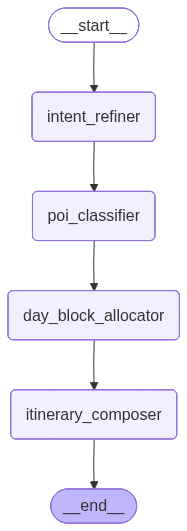

In [5]:
class PlanningState(TypedDict, total=False):
    collect: CollectState
    refined_intent: Dict[str, Any]
    poi_classes: Dict[str, Any]
    allocation: Dict[str, Any]
    plan_markdown: str

from typing import List, Literal, Optional, Dict, TypedDict
from pydantic import BaseModel, Field

class RefinedIntent(BaseModel):
    audience: Literal["solo", "couple", "family"] = Field(..., description="여행자 구성")
    pace: Literal["relaxed", "packed"] = Field(..., description="일정 템포")
    interests: List[str] = Field(..., description="관심사(우선순위 상위부터)")
    food_prefs: Optional[str] = Field(None, description="음식 취향/제약")
    budget_level: Literal["low", "med", "high"] = Field(..., description="예산 레벨")
    hard_constraints: List[str] = Field(default_factory=list, description="알레르기/필수 방문/야간 이동 금지 등 제약")

class POIClass(BaseModel):
    title: str = Field(..., description="장소 이름")
    type: Literal["indoor", "outdoor", "mixed"] = Field(..., description="실내/실외 분류")
    theme: Literal["museum", "temple", "park", "market", "neighborhood", "view", "food", "other"] = Field(..., description="장소 테마")
    priority: int = Field(..., description="우선순위(1~5)")

class POIClassifyResult(BaseModel):
    pois: List[POIClass] = Field(default_factory=list, description="중복 제거된 POI 목록")

class DayAllocation(BaseModel):
    date: str = Field(..., description="YYYY-MM-DD")
    indoor: List[str] = Field(default_factory=list, description="실내 장소 추천")
    outdoor: List[str] = Field(default_factory=list, description="실외 장소 추천")
    notes: str = Field(default="", description="배정 이유 또는 주의사항")

class DayAllocationResult(BaseModel):
    days: List[DayAllocation] = Field(default_factory=list, description="일자별 배정 결과")

intent_llm = llm.with_structured_output(RefinedIntent, method="function_calling")
poi_llm = llm.with_structured_output(POIClassifyResult, method="function_calling")
allocation_llm = llm.with_structured_output(DayAllocationResult, method="function_calling")

def intent_refiner(state: PlanningState) -> Dict:
    """사용자의 지시와 선호가 불명확할 때 목적지를 명시적으로 제약하고 페르소나를 생성"""

    REFINE_PROMPT = ChatPromptTemplate.from_template("""
너는 여행 일정을 조정하기 위해 사용자의 목적을 분석하고 정리하는 역할을 한다.
사용자의 의도를 아래 JSON 스키마에 맞춰 변환하라.

필수 필드:
- audience: 혼자(solo)/연인(couple)/가족(family) 중 선택
- pace: 편안한(relaxed)/패키지(packed) 중 선택
- interests: 중요도 순으로 나열
- budget_level: low/med/high 중 선택
선택 필드:
- food_prefs: 음식 취향/제약
- hard_constraints: 알레르기, 반드시 가야 할 곳, 야간 이동 금지 등

사용자 정보:
- 목적지: {dest}
- 선호 텍스트: {prefs}

누락된 항목은 {dest} 맥락에서 합리적으로 채워라.
반드시 스키마에 맞게 작성하라.
""")

    dest = state["collect"]["destination"]
    prefs = state["collect"].get("preferences") or ""
    result: RefinedIntent = (REFINE_PROMPT | intent_llm).invoke({"dest": dest, "prefs": prefs})
    return {"refined_intent": result.model_dump()}


def poi_classifier(state: PlanningState) -> Dict:
    """위키 제목/스니펫을 바탕으로 관광 명소(indoor/outdoor/theme)를 분류 및 중복 제거"""
    collect = state.get("collect") or {}
    pois = collect.get("pois", [])
    sample = "\n".join([f"- {p.get('title')}: {p.get('snippet','')}" for p in pois[:12]])
    P = ChatPromptTemplate.from_template(
        """
        아래 장소들을 분류하세요.
        필드: title, type(indoor|outdoor|mixed), theme(museum|temple|park|market|neighborhood|view|food|other), priority(1-5).
        중복 항목은 병합하고 결과를 pois 리스트로 반환하세요.

        입력:
        {sample}
        """
    )
    result: POIClassifyResult = (P | poi_llm).invoke({"sample": sample})
    return {"poi_classes": result.model_dump()}


def day_block_allocator(state: PlanningState) -> Dict:
    """날씨 + 사용자의 제약을 고려하여 일별 야외/실내 여행을 할당"""

    w = state["collect"]["weather"]
    start = _iso_to_date(state["collect"]["start_date"])
    days = _date_range(start, state["collect"]["nights"])[:-1]

    daily = w.get("daily", {})
    tmax_l = daily.get("temperature_2m_max") or []
    tmin_l = daily.get("temperature_2m_min") or []
    precip_l = daily.get("precipitation_sum") or []
    wind_l = daily.get("wind_speed_10m_max") or []
    day_rows = []
    for i, d in enumerate(days):
        row = {
            "date": _fmt_day(d),
            "tmax": tmax_l[i] if i < len(tmax_l) else None,
            "tmin": tmin_l[i] if i < len(tmin_l) else None,
            "precip": precip_l[i] if i < len(precip_l) else None,
            "windmax": wind_l[i] if i < len(wind_l) else None,
        }
        day_rows.append(row)

    P = ChatPromptTemplate.from_template(
        """
        일 단위 날씨와 POI 분류를 바탕으로, 가능하면 하루에 실외와 실내 장소를 적절한 수로 배정하세요.
        강수량이 {RAIN}mm 초과, 풍속 {WIND}m/s 초과, 혹은 온도가 [{TMIN},{TMAX}]℃ 범위를 벗어나면 실외를 피합니다.
        결과는 days 리스트(각 원소: date, indoor, outdoor, notes)로 반환하세요.

        날씨:
        {weather}
        POI:
        {pois}
        제약:
        {intent}
        """
    )

    result: DayAllocationResult = (P | allocation_llm).invoke({
        "RAIN": RAIN_MM_OK,
        "WIND": WIND_MPS_MAX,
        "TMIN": TEMP_MIN_C,
        "TMAX": TEMP_MAX_C,
        "weather": day_rows,
        "pois": state.get("poi_classes", {"pois": []}),
        "intent": state.get("refined_intent", {}),
    })
    return {"allocation": result.model_dump()}


def itinerary_composer(state: PlanningState) -> Dict:
    """할당 + 호텔 + 요약을 친절한 마크다운 일정으로 변환"""

    P = ChatPromptTemplate.from_template(
        """
        {dest} {nights}박 {nights}+1일 일정에 대해, 아래 배정 JSON을 사용해 간결하고 친근한 마크다운 일정을 작성하라:
        {alloc}
        형식: 날짜 헤더, 각 블록에 테마에 맞는 장소 아이디어(구체적 지명 가상 제시 가능),
        하루 한 줄의 간단 교통 팁, 그리고 "이 일정이 좋은 이유" 소제목을 덧붙여라.
        호텔 목록이 있다면 짧게 추가하라:
        {hotels}
        도시 스냅샷(불릿 5개)도 포함하라:
        {summary}
        """
    )
    hotels_md = "\n".join([f"- {h['name']}" + (f" ({h['stars']}★)" if h.get('stars') else "") for h in state["collect"].get("hotels", [])[:8]])
    out = (P | llm | StrOutputParser()).invoke({
        "dest": state["collect"]["destination"], "nights": state["collect"]["nights"],
        "alloc": state.get("allocation", {}),
        "hotels": hotels_md or "(no hotel data)",
        "summary": state["collect"].get("wiki_summary","(no summary)")
    })
    return {"plan_markdown": out}

g = StateGraph(PlanningState)
g.add_node("intent_refiner", intent_refiner)
g.add_node("poi_classifier", poi_classifier)
g.add_node("day_block_allocator", day_block_allocator)
g.add_node("itinerary_composer", itinerary_composer)

g.add_edge(START, "intent_refiner")
g.add_edge("intent_refiner", "poi_classifier")
g.add_edge("poi_classifier", "day_block_allocator")
g.add_edge("day_block_allocator", "itinerary_composer")
g.add_edge("itinerary_composer", END)

planning_graph = g.compile()
draft = planning_graph.invoke({"collect":collected_data})
print(draft)
planning_graph

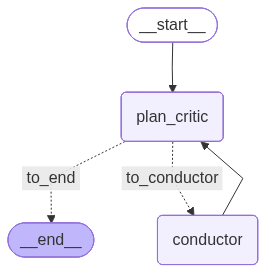

In [6]:
class ReviseState(TypedDict, total=False):
    plan_markdown: str
    revisions: int
    critique: str
    ok: bool  # plan_critic 결과 True면 수정 없이 종료

MAX_REVISIONS = 3

class CriticResult(BaseModel):
    ok: bool = Field(..., description="현재 계획이 그대로 실행 가능하면 true")
    patch: str = Field(default="", description="수정이 필요할 때 최소 수정 지시")


critic_llm = llm.with_structured_output(CriticResult, method="function_calling")


def plan_critic(state: ReviseState) -> Dict:
    """날씨/제약에 대한 실현 가능성 평가"""
    P = ChatPromptTemplate.from_template(
        """
        아래 일정을 날씨 임계치(강수>{RAIN}mm, 풍속>{WIND}m/s, 온도 [{TMIN},{TMAX}]℃ 범위 밖)와 사용자 제약에 비추어 검토하세요.
        문제가 있으면 전체를 재작성하지 말고, 실내로 전환/시간대 이동/실외 축소 등의 '최소 수정' 목록만 제안하세요.

        출력 규칙:
        - 실행 가능하면 ok=true
        - 수정 필요하면 ok=false, patch에 수정 요약 작성

        계획:
        {plan}
        """
    )
    result: CriticResult = (P | critic_llm).invoke({
        "RAIN": RAIN_MM_OK,
        "WIND": WIND_MPS_MAX,
        "TMIN": TEMP_MIN_C,
        "TMAX": TEMP_MAX_C,
        "plan": state.get("plan_markdown", ""),
    })
    return {"ok": result.ok, "critique": result.patch}


def conductor(state: ReviseState) -> Dict:
    """수정이 필요한 경우에만 호출됨"""
    revs = int(state.get("revisions", 0))
    patch = state.get("critique", "")
    plan = state.get("plan_markdown", "")
    
    import json as _json
    
    P = ChatPromptTemplate.from_template(
        """
        >> 다음 패치 노트를 반영해 일정을 최소한으로 수정하세요:
        요청자는 한국인이므로 외국어를 모르는 한국인을 배려해서 결과를 작성하세요.
        {patch}

        >> 원본 계획:
        {plan}

        >> 원본에서 수정한 최종 여행 계획만 출력하세요. 다른 설명은 생략합니다.
        """
    )
    out = (P | llm | StrOutputParser()).invoke({"patch": patch, "plan": plan})
    
    # ok는 plan_critic만 써야 함(한 스텝에 한 값만 허용). 수정 후엔 plan_critic이 다시 실행되며 ok를 설정함.
    return {"plan_markdown": out, "revisions": revs + 1}

def route_after_critic(state: ReviseState) -> Literal["to_conductor", "to_end"]:
    # ok가 True이면 바로 종료
    if state.get("ok") is True:
        return "to_end"
    # 이미 최대 수정을 거쳤다면 종료
    if int(state.get("revisions", 0)) >= MAX_REVISIONS:
        return "to_end"
    # 수정이 필요하면 conductor로 이동
    return "to_conductor"

g = StateGraph(ReviseState)
g.add_node("plan_critic", plan_critic)
g.add_node("conductor", conductor)

g.add_edge(START, "plan_critic")
# 2. Critic 결과에 따른 조건부 분기 (핵심!)
g.add_conditional_edges(
    "plan_critic",
    route_after_critic,
    {
        "to_conductor": "conductor",
        "to_end": END
    }
)
# 3. Conductor는 수정을 마친 후 다시 Critic에게 검사를 받으러 감
g.add_edge("conductor", "plan_critic")

revise_graph = g.compile()

revise_graph

In [7]:
result = revise_graph.invoke({"plan_markdown": draft, "revisions": 3})
result['plan_markdown']

{'collect': {'destination': 'Paris',
  'start_date': '2026-2-27',
  'nights': 3,
  'preferences': 'I like to eat out and go to museums',
  'tz': 'Europe/Paris',
  'lat': 48.85341,
  'lon': 2.3488,
  'weather': {'latitude': 48.86,
   'longitude': 2.3399997,
   'generationtime_ms': 0.24449825286865234,
   'utc_offset_seconds': 3600,
   'timezone': 'Europe/Paris',
   'timezone_abbreviation': 'GMT+1',
   'elevation': 43.0,
   'hourly_units': {'time': 'iso8601',
    'temperature_2m': '°C',
    'precipitation': 'mm',
    'windspeed_10m': 'km/h'},
   'hourly': {'time': ['2026-02-27T00:00',
     '2026-02-27T01:00',
     '2026-02-27T02:00',
     '2026-02-27T03:00',
     '2026-02-27T04:00',
     '2026-02-27T05:00',
     '2026-02-27T06:00',
     '2026-02-27T07:00',
     '2026-02-27T08:00',
     '2026-02-27T09:00',
     '2026-02-27T10:00',
     '2026-02-27T11:00',
     '2026-02-27T12:00',
     '2026-02-27T13:00',
     '2026-02-27T14:00',
     '2026-02-27T15:00',
     '2026-02-27T16:00',
     '2026

In [8]:
print(result['plan_markdown']['plan_markdown'])

## 2026-02-27
- 테마 아이디어
  - Musée Pasteur에서 백신과 면역학의 역사를 따라가는 실내 투어
  - UNESCO Headquarters에서 국제 문화 교류와 세계문화유산의 보존 이야기를 체험하는 가상 전시
  - 실내 카페 루프탑 대신 파리식 디저트를 즐기는 간단 브레이크
- 교통 팁
  - 지하철 1호선을 이용해 중심으로 이동 후 UNESCO 앞까지 도보로 연결하기 좋습니다.
- 이 일정이 좋은 이유
  - 바람과 비를 피하며 실내에서 집중적으로 파리를 만날 수 있어요.

## 2026-02-28
- 테마 아이디어
  - Musée Pasteur의 과학사 2부: 현장 자료와 실험 기록을 따라가는 로드맵
  - UNESCO Headquarters에서 국제 협력의 사례를 다루는 인터랙티브 전시 보기
  - 도서관형 카페에서 파리의 문학과 커피의 조합 체험
- 교통 팁
  - 메트로 1호선 + 8호선으로 중심부를 빠르게 연결하고 도보로 가까운 indoor 명소로 이동하기 좋습니다.
- 이 일정이 좋은 이유
  - 비가 내려도 indoors 위주로 차분하게 파리의 지성과 문화를 깊이 즐길 수 있어요.

## 2026-03-01
- 테마 아이디어
  - Musée Pasteur의 현대 과학 이슈 짚어보기: 백신 개발의 오늘과 미래 토론
  - UNESCO Headquarters에서 세계문화 다양성의 현재를 조명하는 디지털 투어
  - 비오는 날에도 즐길 수 있는 파리지앵 스타일의 실내 골프/보드게임 카페 체험
- 교통 팁
  - 지하철과 버스를 적절히 배합해 실내 방문 루트를 매끄럽게 연결하기 좋습니다.
- 이 일정이 좋은 이유
  - 최저 기온이 낮아 야외 활동이 어렵더라도 indoors에서 알찬 방문을 유지할 수 있습니다.

- 호텔 추천
  - Ibis
  - Hôtel Saint-Honoré (3★)
  - Hôtel Montpensier (2★)
  - Hôtel Louvre Bon Enfants (3★)
  - Hôtel Cos

In [9]:
import time

class TripState(TypedDict, total=False):
    collect: CollectState
    planning: PlanningState
    revise: ReviseState

def collect_agent(state: TripState) -> Dict:
    """여행 정보 수집"""
    print('collecting...')
    tic = time.perf_counter()
    collected = collect_graph.invoke(state['collect'])
    toc = time.perf_counter()
    print(f'collecting done : {toc-tic:.2f}s')

    return {"collect": collected}

def planning_agent(state: TripState) -> Dict:
    """여행 계획 작성"""
    print('planning...')
    tic = time.perf_counter()
    state["planning"]['collect'] = state['collect']
    planning = planning_graph.invoke(state['planning'])
    toc = time.perf_counter()
    print(f'planning done : {toc-tic:.2f}s')
    return {"planning": planning}

def revise_agent(state: TripState) -> Dict:
    """여행 계획 수정"""
    print('revising...')
    tic = time.perf_counter()
    state["revise"]['plan_markdown'] = state['planning']['plan_markdown']
    revised = revise_graph.invoke(state['revise'])
    toc = time.perf_counter()
    print(f'revising done : {toc-tic:.2f}s')
    return {"revise": revised}

g = StateGraph(TripState)
g.add_node("collect_agent", collect_agent)
g.add_node("planning_agent", planning_agent)
g.add_node("revise_agent", revise_agent)

g.add_edge(START, "collect_agent")
g.add_edge("collect_agent", "planning_agent")
g.add_edge("planning_agent", "revise_agent")
g.add_edge("revise_agent", END)

trip_graph = g.compile()

user_needs = {'destination':'대만 카오슝','start_date':'2026-02-27','nights':3,'preferences':'아기와 함께, 다양한 경험, 바다와 산책'}
result = trip_graph.invoke({"collect": user_needs, "planning": {}, "revise": {"revisions": 0}})

collecting...
collecting done : 18.50s
planning...
planning done : 70.23s
revising...
revising done : 60.60s


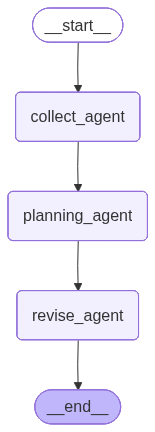

In [10]:
trip_graph

In [11]:
print(result['revise']['plan_markdown'])

## 2026-02-27

- 테마 아이디어 (구체적 지명 가상 제시 가능)
  - Oceanus Hall 해양 박물관
  - BlueMirror 실내 수족관 전시관
  - FamilyLab 가족 친화 문화센터 체험 공간

- 교통 팁: 실내 위주 동선으로 호텔에서 가까운 지하철역으로 이동해 유모차 용이한 경로를 확보. 비/강풍 시에도 완전 실내 동선 확보를 우선.

- 실외 활동 대체 및 비상 대체 플랜
  - 주 루트: 호텔 ↔ 지하철역 → 전시관
  - 비상 대체 공간(동일 테마): Oceanus Hall, BlueMirror, SeaInsight, CoralSphere Indoor Aquarium, Oceanic Dome
  - 대체 경로 예시(완전 실내 루트)
    - 루트 A: 호텔 지하 연결통로 → 쇼핑몰 실내동(연결 통로) → 지하철역
    - 루트 B: 호텔 지하 1층의 실내 브리지 → 시내 도심 실내 공용 경로 → 지하철역
    - 루트 C: 호텔 지하 전용 에스컬레이터/엘리베이터 이용해 바로 지하철역으로

- 야간 이동 여부 및 일정 조정
  - 현재 구간들 중 야간 이동 필요 없음. 필요 시 낮 시간대 재배치 가능.

- 우천·강풍 시 대체 장소(동일 테마의 실내 공간)
  - 해양 테마 대체 공간: Oceanus Hall, BlueMirror, SeaInsight, CoralSphere Indoor Aquarium
  - 과학/체험 테마 대체 공간: Discovery Dome, Oceanic Dome, MarinaLab Indoor Science Center
  - 실내 예술/문화 테마 대체 공간: ModernView(실내 전시) / Indoor Creative Lab

- 온도 관리
  - 모든 실내 공간의 평균 온도 10–30°C 범위 유지 확인. 필요 시 난방/냉방 계획 확정 및 현지 안내.

- 이 일정이 좋은 이유
  - 비가 와도 완전 실내 체험 위주로 구성되어 휴식과 여유를 챙길 수 있음
  - 유모차 동선이 편한 루트